# Politically Motivated Crime in Germany: Right-Wing Offences and AfD Election Results

### Part 2: Analysis. Police statistics (PMK) and official election data, 2014 to 2025

This notebook analyses how right-wing motivated offences in Germany developed from 2014 to 2025. It uses only official, public data: the statistics on politically motivated crime (Politisch motivierte Kriminalität, PMK) published by the BKA and BMI, and the election results published by the Federal Returning Officer. The data was prepared in `01_data_preparation.ipynb`.

Four questions are answered:

1. **Development:** how did the number of right-wing motivated offences and of violent offences develop from 2014 to 2025?
2. **Types of offence:** which types of offence make up the total, and which of them grew most?
3. **Federal states:** how do the 16 federal states differ in offences per 100,000 inhabitants, and how did each state change from 2022 to 2025?
4. **AfD election results:** how do the election results of the AfD in the federal states compare with the rate of right-wing offences?

Question 4 puts two sets of figures side by side. It does not claim that one causes the other (Section 9 and Section 10).

Which offences count as right-wing motivated is not defined in this project. The classification of the police is used (phenomenon area "PMK -rechts-").

Python is used for loading, checking, analysis and charts.

| Area | Scope |
|---|---|
| Subject | Politically motivated crime, phenomenon area right-wing (PMK -rechts-), as recorded by the police and published by the BKA and BMI |
| Period | 2014 to 2025 at federal level; 2022 to 2025 for the federal states |
| Federal data | `pmk_right_federal.csv`: one row per year and type of offence |
| State data | `pmk_right_states.csv`: one row per federal state and year, with population and rates |
| Election data | `afd_results.csv`: AfD share of votes per federal state in six elections |
| Measures | Registered offences, violent offences, offences per 100,000 inhabitants, AfD share of votes in % |
| Output | Nine charts in `figures/` |

German terms used in this notebook:

| German term | Term in this notebook |
|---|---|
| Politisch motivierte Kriminalität (PMK) | Politically motivated crime |
| PMK -rechts- | Right-wing motivated offences |
| Gewaltdelikte | Violent offences |
| Propagandadelikte | Propaganda offences: distributing propaganda material and using symbols of unconstitutional organisations |
| Volksverhetzung | Incitement to hatred (§ 130 StGB) |
| Beleidigung | Insult (§§ 185 to 188 StGB) |
| Sachbeschädigung | Property damage |
| Nötigung/Bedrohung | Coercion and threat |
| Bundestagswahl / Europawahl | Federal election / European election |

## 1. Import Libraries

In [1]:
from pathlib import Path

import math

import pandas as pd
import matplotlib.pyplot as plt

## 2. Define Parameters and File Paths

The folder `data/clean` is searched upwards from the notebook folder, so the notebook runs from any subfolder of the project.

The federal states are compared for 2022 to 2025, the only years with figures per state. For the types of offence the comparison starts in 2019, the first year in which all six types are available.

The 16 federal states are put into three groups, because they differ in a systematic way (Sections 8 and 9): the five eastern states, the three city states and the eight western area states. Berlin is counted as a city state, not as an eastern state, because it consists of the former East and West Berlin.

In [2]:
# Locate data/clean by walking up from the notebook folder
start = Path.cwd()
DATA_CLEAN = next(p / "data" / "clean" for p in [start, *start.parents] if (p / "data" / "clean").exists())
FIGURES = DATA_CLEAN.parent.parent / "figures"
FIGURES.mkdir(exist_ok=True)

FEDERAL_CSV = DATA_CLEAN / "pmk_right_federal.csv"     # federal level, 2014 to 2025
STATES_CSV = DATA_CLEAN / "pmk_right_states.csv"       # federal states, 2022 to 2025
AFD_CSV = DATA_CLEAN / "afd_results.csv"               # AfD share of votes, six elections

FIRST_YEAR, LAST_YEAR = 2014, 2025
FIRST_YEAR_TYPES = 2019                                # first year with all six types of offence
FIRST_YEAR_STATES = 2022                               # first year with figures per federal state

# Types of offence in the federal table, with the label used in charts and tables
OFFENCE_TYPES = {
    "propaganda": "Propaganda offences",
    "incitement_to_hatred": "Incitement to hatred",
    "insult": "Insult",
    "property_damage": "Property damage",
    "violent": "Violent offences",
    "coercion_threat": "Coercion and threat",
}
OTHER = "Other offences"                               # total minus the six types

# Three groups of federal states (grouping made in this project, not by the police)
STATE_GROUPS = {
    "Eastern states": ["Brandenburg", "Mecklenburg-Western Pomerania", "Saxony", "Saxony-Anhalt", "Thuringia"],
    "City states": ["Berlin", "Bremen", "Hamburg"],
    "Western area states": ["Baden-Württemberg", "Bavaria", "Hesse", "Lower Saxony", "North Rhine-Westphalia",
                            "Rhineland-Palatinate", "Saarland", "Schleswig-Holstein"],
}
GROUP_OF_STATE = {state: group for group, members in STATE_GROUPS.items() for state in members}

# Chart style
BLUE, MUTED, ORANGE, GREEN = "#1f5a94", "#8a8a8a", "#eb6834", "#1baf7a"
GROUP_COLORS = {"Eastern states": ORANGE, "City states": GREEN, "Western area states": BLUE}
TYPE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#b5b5b5"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

SOURCE_FEDERAL = ("Source: Federal Criminal Police Office (BKA) and Federal Ministry of the Interior (BMI), "
                  "figures on politically motivated crime\n2018 to 2025; German Bundestag, printed paper 18/5758 (2014).")
SOURCE_STATES = ("Source: German Bundestag, printed papers 20/7594, 21/1418 and 21/5639 (offences); "
                 "Destatis, table 12411-0010 (population, 31 December).\nOwn calculation: offences per 100,000 inhabitants.")

## 3. Load the Data

Three tables are loaded. They were prepared and checked in `01_data_preparation.ipynb`.

| Column | Meaning |
|---|---|
| `year` | Reporting year, or year of the election |
| `offence`, `cases` | Type of offence and registered offences (federal table) |
| `state` | Federal state; `Germany` for the national result (election table) |
| `total`, `violent` | Registered offences and violent offences (state table) |
| `population` | Inhabitants on 31 December |
| `total_per_100k`, `violent_per_100k` | Offences per 100,000 inhabitants |
| `election` | `federal` or `european` |
| `afd_share_pct` | AfD share of valid votes in % (second vote in federal elections) |

In [3]:
federal_long = pd.read_csv(FEDERAL_CSV)
states = pd.read_csv(STATES_CSV)
afd = pd.read_csv(AFD_CSV)

tables = {"federal_long": federal_long, "states": states, "afd": afd}

## 4. Check Data Quality

The general check covers table size, missing values, duplicate rows and text in number columns.

In [4]:
# One summary row per table
number_columns = {"federal_long": ["cases"],
                  "states": ["total", "violent", "population", "total_per_100k", "violent_per_100k"],
                  "afd": ["afd_votes", "afd_share_pct"]}
quality = pd.DataFrame({
    name: {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        # values that are present but cannot be read as a number
        "non_numeric_values": int(sum(
            (pd.to_numeric(df[c], errors="coerce").isna() & df[c].notna()).sum()
            for c in number_columns[name])),
    }
    for name, df in tables.items()
}).T
quality

,rows,columns,missing_values,duplicate_rows,non_numeric_values
federal_long,69,4,0,0,0
states,64,7,0,0,0
afd,102,5,0,0,0


The three tables have no missing values, no duplicate rows and no text in number columns.

In [5]:
# First rows of each table
for name, df in tables.items():
    print(name)
    display(df.head(3))

federal_long


,year,offence,cases,source
0,2014,total,17020,"1805758.pdf, PDF-Seite 4"
1,2014,violent,1029,"1805758.pdf, PDF-Seite 4"
2,2014,propaganda,11071,"1805758.pdf, PDF-Seite 8"


states


,year,state,total,violent,population,total_per_100k,violent_per_100k
0,2022,Baden-Württemberg,1459,36,11167721,13.1,0.32
1,2022,Bavaria,2541,111,13105221,19.4,0.85
2,2022,Berlin,2189,138,3632853,60.3,3.80


afd


,election,year,state,afd_votes,afd_share_pct
0,european,2014,Baden-Württemberg,309500,7.88
1,european,2014,Bavaria,311982,8.06
2,european,2014,Berlin,91759,7.91


## 5. Check Coverage: Years, Federal States and Types of Offence

Before any calculation the tables are checked against the questions: the federal table must cover 2014 to 2025, the state table must contain all 16 federal states in every year from 2022 to 2025, and the election table must contain the same 16 states.

In [6]:
print("Federal table: years", federal_long["year"].min(), "to", federal_long["year"].max(),
      "| duplicate year-offence pairs:", federal_long.duplicated(["year", "offence"]).sum())
print("State table: years", states["year"].min(), "to", states["year"].max(),
      "|", states["state"].nunique(), "states",
      "| duplicate year-state pairs:", states.duplicated(["year", "state"]).sum())
print("Election table:", afd.groupby(["year", "election"]).size().to_dict())
print("Same state names in state and election table:",
      set(states["state"]) == set(afd["state"]) - {"Germany"})
print("Every state belongs to exactly one group:",
      sorted(GROUP_OF_STATE) == sorted(states["state"].unique()) and len(GROUP_OF_STATE) == 16)

# Federal table from long to wide: one row per year, one column per type of offence
federal = federal_long.pivot(index="year", columns="offence", values="cases")[["total"] + list(OFFENCE_TYPES)]
federal.notna().astype(int).rename(columns=OFFENCE_TYPES)     # 1 = value available

Federal table: years 2014 to 2025 | duplicate year-offence pairs: 0
State table: years 2022 to 2025 | 16 states | duplicate year-state pairs: 0
Election table: {(2014, 'european'): 17, (2017, 'federal'): 17, (2019, 'european'): 17, (2021, 'federal'): 17, (2024, 'european'): 17, (2025, 'federal'): 17}
Same state names in state and election table: True
Every state belongs to exactly one group: True


offence,total,Propaganda offences,Incitement to hatred,Insult,Property damage,Violent offences,Coercion and threat
year,,,,,,,
2014,1,1,1,0,1,1,1
2015,1,0,0,0,0,1,0
2016,1,0,0,0,0,1,0
2017,1,1,1,0,1,1,1
2018,1,1,1,0,1,1,1
2019,1,1,1,1,1,1,1
2020,1,1,1,1,1,1,0
2021,1,1,1,1,1,1,0
2022,1,1,1,1,1,1,1


All years and all 16 federal states are present, the names of the states match between the tables, and every state belongs to exactly one of the three groups.

The total and the violent offences are available for all twelve years. The other types of offence have gaps: all are missing for 2015 and 2016, insult is available from 2019 only, and coercion and threat is missing for 2020 and 2021. The reasons are given in `01_data_preparation.ipynb` (Section 10). Question 2 therefore compares only the years in which all six types are available.

## 6. Question 1: Right-Wing Motivated Offences, 2014 to 2025

The table shows the registered offences, the change to the year before, the violent offences and their share in all right-wing motivated offences.

In [7]:
development = federal[["total", "violent"]].astype(int)
development["total_change_pct"] = (100 * development["total"].pct_change()).round(1)
development["violent_change_pct"] = (100 * development["violent"].pct_change()).round(1)
development["violent_share_pct"] = (100 * development["violent"] / development["total"]).round(2)
development[["total", "total_change_pct", "violent", "violent_change_pct", "violent_share_pct"]]

offence,total,total_change_pct,violent,violent_change_pct,violent_share_pct
year,,,,,
2014,17020,NaN,1029,NaN,6.05
2015,22960,34.9,1485,44.3,6.47
2016,23555,2.6,1698,14.3,7.21
2017,20520,-12.9,1130,-33.5,5.51
2018,20431,-0.4,1156,2.3,5.66
2019,22342,9.4,986,-14.7,4.41
2020,23604,5.6,1092,10.8,4.63
2021,21964,-6.9,1042,-4.6,4.74
2022,23493,7.0,1170,12.3,4.98


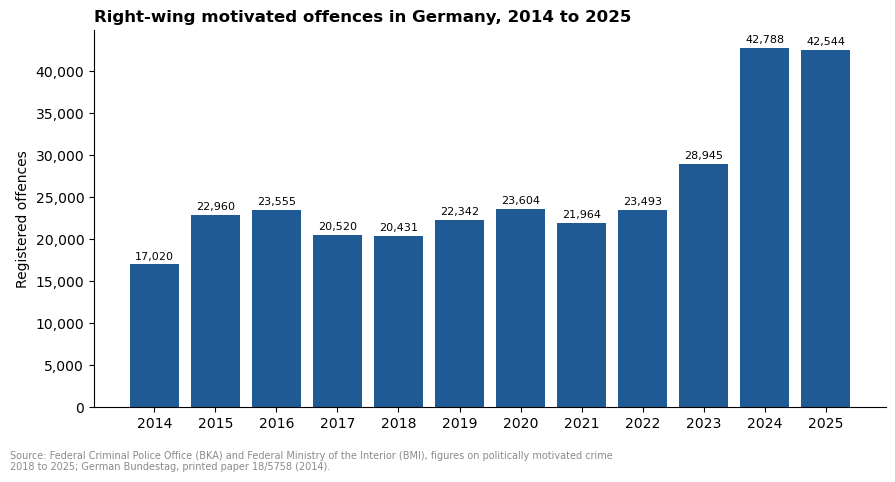

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(development.index, development["total"], color=BLUE)
for year, value in development["total"].items():
    ax.text(year, value + 600, f"{value:,.0f}", ha="center", fontsize=8)
ax.set_title("Right-wing motivated offences in Germany, 2014 to 2025", loc="left", fontweight="bold")
ax.set_ylabel("Registered offences")
ax.set_xticks(development.index)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
fig.text(0.01, 0.01, SOURCE_FEDERAL, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "01_offences_total.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

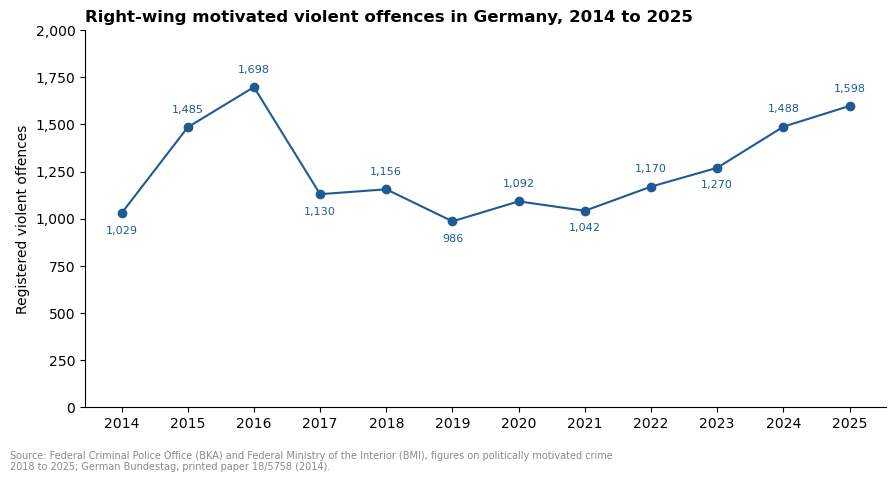

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(development.index, development["violent"], color=BLUE, marker="o")
# Label above the point at a high point, below it at a low point, so the label does not sit on the line
values = development["violent"]
for year, value in values.items():
    neighbours = values.reindex([year - 1, year + 1]).dropna()
    above = value >= neighbours.mean()
    ax.annotate(f"{value:,.0f}", (year, value), xytext=(0, 9 if above else -9), textcoords="offset points",
                ha="center", va="bottom" if above else "top", fontsize=8, color=BLUE)
ax.set_title("Right-wing motivated violent offences in Germany, 2014 to 2025", loc="left", fontweight="bold")
ax.set_ylabel("Registered violent offences")
ax.set_ylim(0, 2000)
ax.set_xticks(development.index)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
fig.text(0.01, 0.01, SOURCE_FEDERAL, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "02_offences_violent.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

Right-wing motivated offences rose from 17,020 in 2014 to 42,544 in 2025, an increase of 150 %. The rise did not happen evenly. It came in two steps:

- **2015:** the number rose by 34.9 % within one year, from 17,020 to 22,960.
- **2015 to 2022:** it stayed between 20,431 and 23,604 for eight years.
- **2023 and 2024:** it rose by 23.2 % and then by 47.8 %, to 42,788 in 2024, the highest value of the period.
- **2025:** 42,544 offences, 0.6 % below 2024.

Violent offences developed differently. They rose from 1,029 in 2014 to 1,698 in 2016, the highest value of the period, and fell to 986 in 2019, the lowest. Since then they have risen in five of six years, to 1,598 in 2025. That is 55.3 % above 2014 and 5.9 % below the peak of 2016.

Violent offences therefore grew much less than all offences. Their share in all right-wing motivated offences fell from 6.05 % in 2014 and 7.21 % in 2016 to 3.76 % in 2025. The strong rise since 2023 comes mainly from offences without violence (Section 7).

The statistics show the development, not its causes. The figures count offences the police registered and classified as right-wing motivated (Section 10).

## 7. Question 2: Types of Offence

The sources give six types of offence. Everything else is summed up here as "other offences": the total minus the six types. This group contains, among others, violations of the law on assemblies and of the weapons law.

The comparison uses the years in which all six types are available: 2019 and 2022 to 2025.

In [10]:
complete = federal.dropna().astype(int)                       # years with all six types
complete[OTHER] = complete["total"] - complete[list(OFFENCE_TYPES)].sum(axis=1)
types = complete.rename(columns=OFFENCE_TYPES)[list(OFFENCE_TYPES.values()) + [OTHER]]

print("Years with all six types:", list(types.index))
# Share of each type in all right-wing motivated offences, in %
shares = (100 * types.div(complete["total"], axis=0)).round(1)
shares

Years with all six types: [2019, 2022, 2023, 2024, 2025]


offence,Propaganda offences,Incitement to hatred,Insult,Property damage,Violent offences,Coercion and threat,Other offences
year,,,,,,,
2019,63.8,13.7,7.9,4.9,4.4,1.9,3.4
2022,60.2,14.8,10.3,3.2,5.0,2.1,4.4
2023,57.7,18.5,9.6,3.4,4.4,2.1,4.3
2024,61.5,15.5,8.4,5.5,3.5,1.9,3.7
2025,59.0,13.0,10.1,6.7,3.8,2.1,5.3


In [11]:
# Change from the first complete year to the last year, per type of offence
first, last = types.loc[FIRST_YEAR_TYPES], types.loc[LAST_YEAR]
type_change = pd.DataFrame({
    f"cases_{FIRST_YEAR_TYPES}": first,
    f"cases_{LAST_YEAR}": last,
    "change": last - first,
    "change_pct": (100 * (last / first - 1)).round(1),
    # how much of the total rise comes from this type
    "share_of_rise_pct": (100 * (last - first) / (last - first).sum()).round(1),
})
type_change.loc["Total"] = [first.sum(), last.sum(), (last - first).sum(),
                            round(100 * (last.sum() / first.sum() - 1), 1), 100.0]
type_change.astype({f"cases_{FIRST_YEAR_TYPES}": int, f"cases_{LAST_YEAR}": int, "change": int})

,cases_2019,cases_2025,change,change_pct,share_of_rise_pct
offence,,,,,
Propaganda offences,14247,25098,10851,76.2,53.7
Incitement to hatred,3062,5547,2485,81.2,12.3
Insult,1770,4297,2527,142.8,12.5
Property damage,1099,2871,1772,161.2,8.8
Violent offences,986,1598,612,62.1,3.0
Coercion and threat,429,894,465,108.4,2.3
Other offences,749,2239,1490,198.9,7.4
Total,22342,42544,20202,90.4,100.0


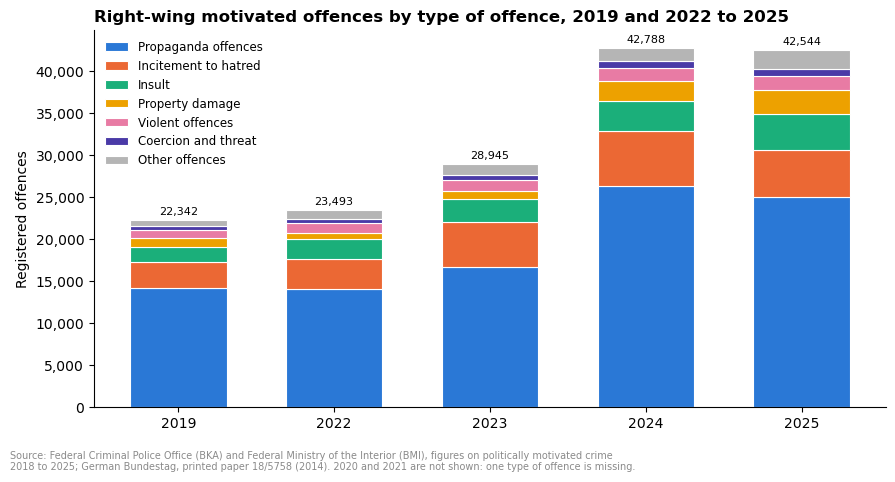

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = [str(year) for year in types.index]
bottom = pd.Series(0.0, index=types.index)
for column, color in zip(types.columns, TYPE_COLORS):
    # White edges keep the segments apart
    ax.bar(x, types[column], bottom=bottom.values, color=color, edgecolor="white", linewidth=0.8, width=0.62, label=column)
    bottom += types[column]
for i, total in enumerate(bottom):
    ax.text(i, total + 600, f"{total:,.0f}", ha="center", fontsize=8)
ax.set_title("Right-wing motivated offences by type of offence, 2019 and 2022 to 2025", loc="left", fontweight="bold")
ax.set_ylabel("Registered offences")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
fig.text(0.01, 0.01, SOURCE_FEDERAL + " 2020 and 2021 are not shown: one type of offence is missing.",
         fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "03_offence_types.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

**Right-wing motivated crime is mostly propaganda offences.** In 2025 they made up 59.0 % of all offences (25,098 cases). Incitement to hatred followed with 13.0 % and insult with 10.1 %. Violent offences were 3.8 %.

**The shares hardly changed, because all types grew.** From 2019 to 2025 the total rose by 90.4 %. Every type of offence rose in this period: propaganda offences by 76.2 %, incitement to hatred by 81.2 %, insult by 142.8 %, property damage by 161.2 %, coercion and threat by 108.4 % and violent offences by 62.1 %.

**More than half of the rise comes from propaganda offences.** They account for 10,851 of the 20,202 additional offences between 2019 and 2025 (53.7 %). Insult accounts for 12.5 %, incitement to hatred for 12.3 % and violent offences for 3.0 %.

**Not every type peaked in the same year.** Incitement to hatred fell from 6,639 in 2024 to 5,547 in 2025, and propaganda offences from 26,318 to 25,098. Insult, property damage, coercion and threat, and violent offences reached their highest value of the period shown here in 2025.

## 8. Question 3: Right-Wing Motivated Offences in the Federal States, 2022 and 2025

The comparison uses offences per 100,000 inhabitants, so states of different size can be compared. Two points in time are shown: 2025 as the main comparison, and 2022 as the first year with figures per state.

The figures for Germany and for the three groups of states are calculated from the sum of offences and the sum of inhabitants of the states in the group.

In [13]:
rate = states.pivot(index="state", columns="year", values="total_per_100k")
ranking = pd.DataFrame({
    "group": pd.Series(GROUP_OF_STATE),
    "rate_2022": rate[FIRST_YEAR_STATES],
    "rate_2025": rate[LAST_YEAR],
    "change_pct": (100 * (rate[LAST_YEAR] / rate[FIRST_YEAR_STATES] - 1)).round(1),
    "rank_2022": rate[FIRST_YEAR_STATES].rank(ascending=False).astype(int),
    "rank_2025": rate[LAST_YEAR].rank(ascending=False).astype(int),
}).sort_values("rate_2025", ascending=False)
ranking

,group,rate_2022,rate_2025,change_pct,rank_2022,rank_2025
Mecklenburg-Western Pomerania,Eastern states,72.5,145.0,100.0,4,1
Saxony-Anhalt,Eastern states,85.9,141.8,65.1,1,2
Brandenburg,Eastern states,80.4,139.4,73.4,2,3
Thuringia,Eastern states,73.4,116.1,58.2,3,4
Saxony,Eastern states,47.0,84.6,80.0,6,5
Berlin,City states,60.3,81.6,35.3,5,6
Hamburg,City states,27.9,81.1,190.7,9,7
Bremen,City states,40.8,78.8,93.1,7,8
Saarland,Western area states,29.3,57.9,97.6,8,9
Schleswig-Holstein,Western area states,23.8,48.6,104.2,10,10


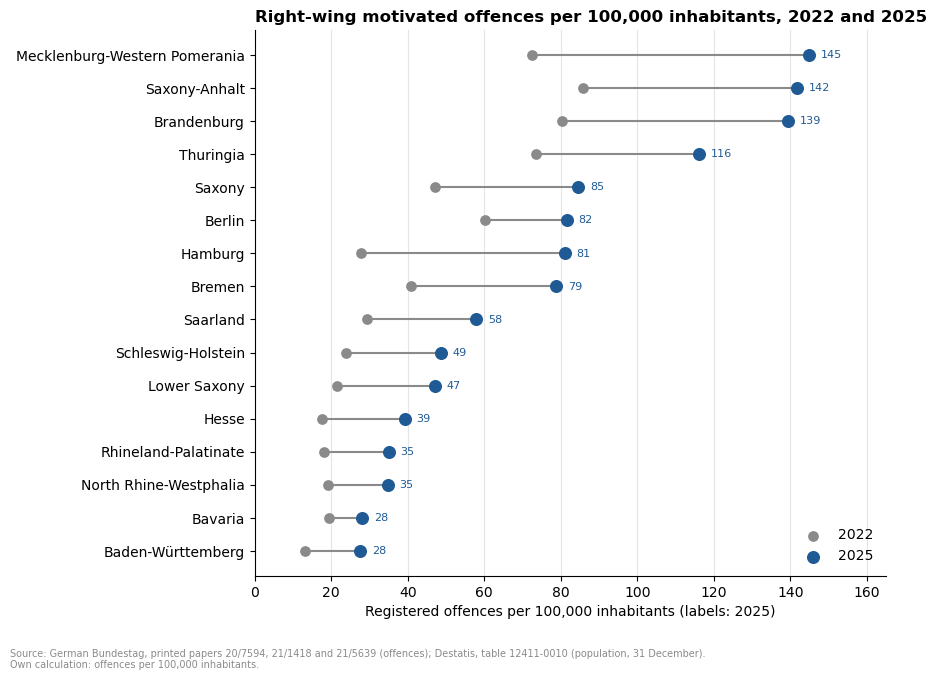

In [14]:
chart = ranking.sort_values("rate_2025")       # smallest value at the bottom of the chart
y = range(len(chart))

fig, ax = plt.subplots(figsize=(9, 6.8))
# One line per state from the 2022 value to the 2025 value
ax.hlines(y, chart["rate_2022"], chart["rate_2025"], color=MUTED, linewidth=1.5, zorder=1)
ax.scatter(chart["rate_2022"], y, color=MUTED, s=45, zorder=2, label="2022")
ax.scatter(chart["rate_2025"], y, color=BLUE, s=70, zorder=3, label="2025")
# The rate rose in every state, so the label stands right of the 2025 point
for i, value in enumerate(chart["rate_2025"]):
    ax.text(value + 3, i, f"{value:.0f}", va="center", ha="left", fontsize=8, color=BLUE)

ax.set_xlim(0, 165)
ax.grid(axis="x", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_yticks(y)
ax.set_yticklabels(chart.index)
ax.set_title("Right-wing motivated offences per 100,000 inhabitants, 2022 and 2025", loc="left", fontweight="bold")
ax.set_xlabel("Registered offences per 100,000 inhabitants (labels: 2025)")
ax.legend(frameon=False, loc="lower right")
fig.text(0.01, 0.01, SOURCE_STATES, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "04_federal_states.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

The chart above shows the first and the last year. The next chart shows all four years for all 16 federal states, sorted by group and by the rate of 2025. The darker a field, the higher the rate.

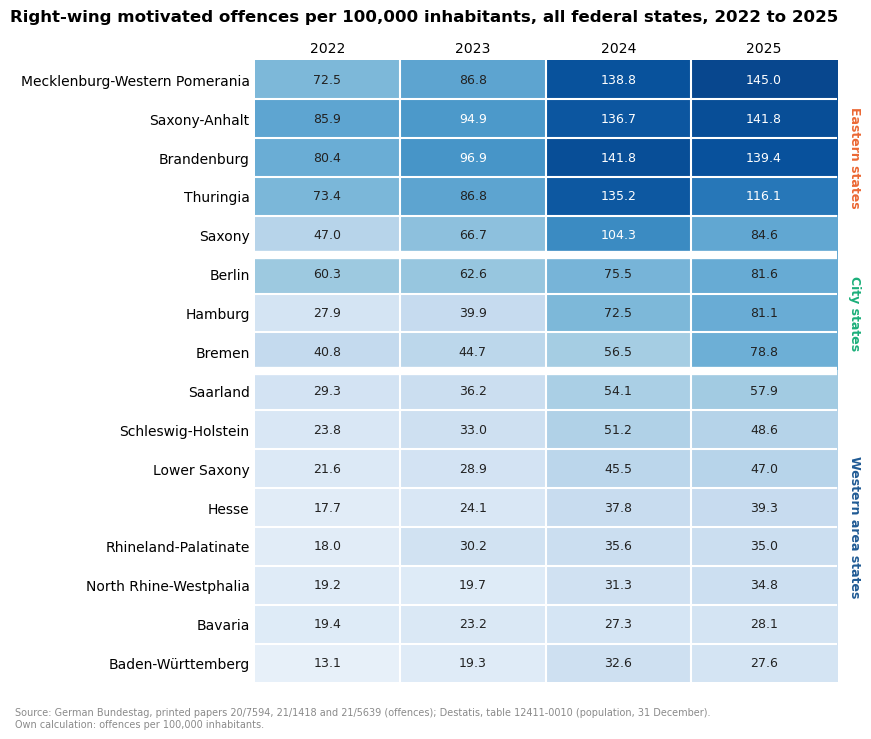

In [15]:
# All 16 states and all four years: states sorted by group, within the group by the rate of 2025
order = [state for group in STATE_GROUPS
         for state in rate.loc[STATE_GROUPS[group]].sort_values(LAST_YEAR, ascending=False).index]
grid = rate.loc[order]

fig, ax = plt.subplots(figsize=(9, 7.4))
image = ax.imshow(grid.values, cmap="Blues", vmin=0, vmax=160, aspect="auto")
for row in range(grid.shape[0]):
    for column in range(grid.shape[1]):
        value = grid.values[row, column]
        ax.text(column, row, f"{value:.1f}", ha="center", va="center", fontsize=9,
                color="white" if value > 90 else "#222222")

# White lines between the fields, and a wider gap with the group name between the three groups
ax.set_xticks([x - 0.5 for x in range(1, grid.shape[1])], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, grid.shape[0])], minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="both", length=0)
position = 0
for group, members in STATE_GROUPS.items():
    if position > 0:
        ax.axhline(position - 0.5, color="white", linewidth=6)
    ax.text(grid.shape[1] - 0.42, position + (len(members) - 1) / 2, group, rotation=270,
            ha="left", va="center", fontsize=9, color=GROUP_COLORS[group], fontweight="bold")
    position += len(members)

ax.set_xticks(range(grid.shape[1]))
ax.set_xticklabels(grid.columns)
ax.xaxis.tick_top()
ax.set_yticks(range(grid.shape[0]))
ax.set_yticklabels(grid.index)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("Right-wing motivated offences per 100,000 inhabitants, all federal states, 2022 to 2025",
             loc="left", fontweight="bold", pad=28, x=-0.42)
fig.text(0.01, 0.01, SOURCE_STATES, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.05, 0.97, 1))
fig.savefig(FIGURES / "05_federal_states_all_years.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

The differences between the federal states are large. In 2025 Mecklenburg-Western Pomerania recorded 145.0 right-wing motivated offences per 100,000 inhabitants and Baden-Württemberg 27.6, a factor of 5.3.

**The rate rose in all 16 federal states.** The smallest increases from 2022 to 2025 are in Berlin (+35.3 %) and Bavaria (+44.8 %), the largest in Hamburg (+190.7 %), Hesse (+122.0 %) and Lower Saxony (+117.6 %).

**The same four states lead in both years.** Mecklenburg-Western Pomerania, Saxony-Anhalt, Brandenburg and Thuringia hold ranks 1 to 4 in 2022 and in 2025, in a different order. Saxony follows on rank 5 in 2025.

**The three city states come next.** Berlin, Hamburg and Bremen hold ranks 6 to 8 in 2025, with rates between 78.8 and 81.6. The eight western area states hold ranks 9 to 16.

The ranking therefore falls into three groups of states. The next cell calculates the rates for these groups.

In [16]:
# Germany and the three groups of states, calculated from offences and population
states["group"] = states["state"].map(GROUP_OF_STATE)

def group_rates(df, by):
    sums = df.groupby(by)[["total", "violent", "population"]].sum()
    return pd.DataFrame({"states": df.groupby(by)["state"].nunique(),
                         "total_per_100k": (100_000 * sums["total"] / sums["population"]).round(1),
                         "violent_per_100k": (100_000 * sums["violent"] / sums["population"]).round(2),
                         "total": sums["total"], "population": sums["population"]})

groups = group_rates(states, ["group", "year"])
germany = group_rates(states, "year")
groups["share_of_offences_pct"] = (100 * groups["total"] / germany["total"]).round(1)
groups["share_of_population_pct"] = (100 * groups["population"] / germany["population"]).round(1)
# Change of the rate since the first year with state figures
groups["change_since_2022_pct"] = (100 * (groups["total_per_100k"]
                                          / groups.groupby("group")["total_per_100k"].transform("first") - 1)).round(1)

display(germany.loc[[FIRST_YEAR_STATES, LAST_YEAR], ["states", "total_per_100k", "violent_per_100k"]])
groups.loc[(list(STATE_GROUPS), [FIRST_YEAR_STATES, LAST_YEAR]),
           ["states", "total_per_100k", "change_since_2022_pct", "violent_per_100k",
            "share_of_offences_pct", "share_of_population_pct"]]

,states,total_per_100k,violent_per_100k
year,,,
2022,16,28.3,1.41
2025,16,51.0,1.91


states  total_per_100k  change_since_2022_pct  \
group               year                                                  
Eastern states      2022       5            68.3                    0.0   
                    2025       5           118.7                   73.8   
City states         2022       3            48.4                    0.0   
                    2025       3            81.2                   67.8   
Western area states 2022       8            18.6                    0.0   
                    2025       8            35.1                   88.7   

                          violent_per_100k  share_of_offences_pct  \
group               year                                            
Eastern states      2022              3.69                   36.2   
                    2025              4.44                   34.5   
City states         2022              3.44                   12.7   
                    2025              4.22                   12.0   
Western area states 2022              0.77                   51.1   
                    2025              1.21                   53.6   

                          share_of_population_pct  
group               year                           
Eastern states      2022                     15.0  
                    2025                     14.8  
City states         2022                      7.4  
                    2025                      7.5  
Western area states 2022                     77.6  
                    2025                     77.7

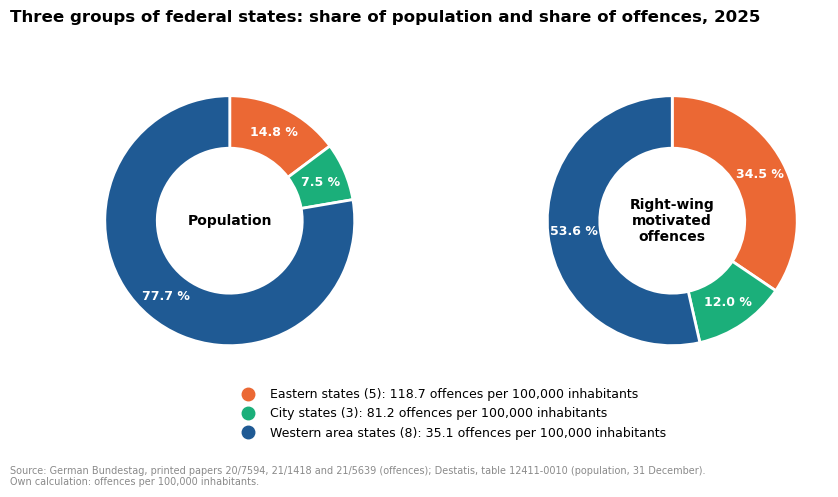

In [17]:
# Share of the three groups in the population and in the offences, 2025
last = groups.xs(LAST_YEAR, level="year").loc[list(STATE_GROUPS)]
colors = [GROUP_COLORS[group] for group in last.index]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.9))
for ax, column, centre in [(axes[0], "share_of_population_pct", "Population"),
                           (axes[1], "share_of_offences_pct", "Right-wing\nmotivated\noffences")]:
    ax.pie(last[column], colors=colors, startangle=90, counterclock=False,
           wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2})
    ax.text(0, 0, centre, ha="center", va="center", fontsize=10, fontweight="bold")
    # Share in % on each segment
    angle = 90.0
    for value in last[column]:
        middle = math.radians(angle - value * 1.8)
        ax.text(0.79 * math.cos(middle), 0.79 * math.sin(middle), f"{value:.1f} %",
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        angle -= value * 3.6

labels = [f"{group} ({int(row['states'])}): {row['total_per_100k']:.1f} offences per 100,000 inhabitants"
          for group, row in last.iterrows()]
handles = [plt.Line2D([], [], marker="o", linestyle="", color=color, markersize=9) for color in colors]
fig.legend(handles, labels, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 0.08), fontsize=9)
fig.suptitle("Three groups of federal states: share of population and share of offences, 2025",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.text(0.01, 0.01, SOURCE_STATES, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.2, 1, 0.96))
fig.savefig(FIGURES / "06_groups_of_states.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

In [18]:
# Violent offences per 100,000 inhabitants, all four years
violent_rate = states.pivot(index="state", columns="year", values="violent_per_100k")
violent_rate.sort_values(LAST_YEAR, ascending=False)

year,2022,2023,2024,2025
state,,,,
Mecklenburg-Western Pomerania,5.14,5.01,7.18,6.55
Hamburg,3.16,3.02,6.23,6.42
Thuringia,4.39,4.40,6.33,6.11
Brandenburg,3.54,4.58,4.42,5.68
Saxony-Anhalt,5.16,5.74,4.96,4.24
Berlin,3.80,3.36,2.42,3.59
Saarland,2.08,2.37,1.98,3.28
Saxony,2.07,1.85,3.07,2.09
Schleswig-Holstein,1.57,2.74,2.20,1.96


**The three groups differ clearly.** In 2025 the five eastern states recorded 118.7 right-wing motivated offences per 100,000 inhabitants, the three city states 81.2 and the eight western area states 35.1. The figure for Germany is 51.0. The eastern states have 14.8 % of the population and 34.5 % of the offences. The city states have 7.5 % of the population and 12.0 % of the offences, the western area states 77.7 % and 53.6 %.

**All three groups rose, and the order stayed.** In 2022 the rates were 68.3, 48.4 and 18.6, and 28.3 for Germany. The rate rose by 73.8 % in the eastern states, by 67.8 % in the city states and by 88.7 % in the western area states.

**In violent offences the city states are close to the eastern states.** In 2025 the eastern states recorded 4.44 violent offences per 100,000 inhabitants, the city states 4.22 and the western area states 1.21. The highest values of single states are in Mecklenburg-Western Pomerania (6.55), Hamburg (6.42) and Thuringia (6.11), the lowest in Baden-Württemberg (0.93). The numbers per state are small: Bremen recorded 12 violent offences in 2025, Saarland 33. Single cases move these rates noticeably from year to year.

The tables do not show why the states differ. The police of each state record and classify the offences on their own responsibility, so differences in recording practice cannot be separated from differences in the offences committed (Section 10).

## 9. Question 4: AfD Election Results Alongside the Offence Rates

This section puts two sets of figures side by side: the share of votes for the AfD and the right-wing motivated offences. It does so first for Germany as a whole over time, and then for the federal states.

For the federal states two pairs are possible, because an election took place in two of the four years with state figures:

- **2025:** federal election of 23 February 2025 and offences of 2025.
- **2024:** European election of 9 June 2024 and offences of 2024.

The correlation coefficient describes how closely two series move together across the states: +1 means the same order, 0 no relation, −1 the opposite order. It says nothing about cause and effect. It is calculated for all 16 states and within the groups of states from Section 8. For the three city states no coefficient is given, because three values do not carry one.

In [19]:
# Germany as a whole: AfD result in each election next to the offences of the same year
national = afd[afd["state"] == "Germany"].set_index("year")[["election", "afd_share_pct"]]
national.join(federal[["total", "violent"]].astype(int))

,election,afd_share_pct,total,violent
year,,,,
2014,european,7.05,17020,1029
2017,federal,12.64,20520,1130
2019,european,10.98,22342,986
2021,federal,10.34,21964,1042
2024,european,15.89,42788,1488
2025,federal,20.80,42544,1598


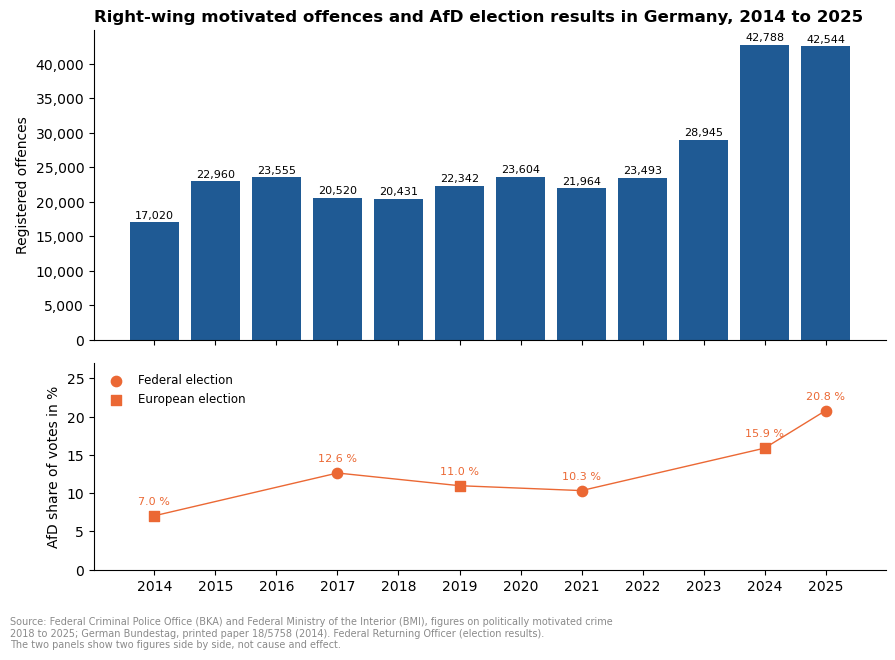

In [20]:
# Germany as a whole in one figure: offences per year (top) and AfD result in each election (bottom)
fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 6.6), sharex=True, height_ratios=[3, 2])

top.bar(development.index, development["total"], color=BLUE)
for year, value in development["total"].items():
    top.text(year, value + 600, f"{value:,.0f}", ha="center", fontsize=8)
top.set_title("Right-wing motivated offences and AfD election results in Germany, 2014 to 2025", loc="left", fontweight="bold")
top.set_ylabel("Registered offences")
top.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")

bottom.plot(national.index, national["afd_share_pct"], color=ORANGE, linewidth=1, zorder=1)
for election, marker, label in [("federal", "o", "Federal election"), ("european", "s", "European election")]:
    part = national[national["election"] == election]
    bottom.scatter(part.index, part["afd_share_pct"], color=ORANGE, marker=marker, s=55, zorder=2, label=label)
for year, value in national["afd_share_pct"].items():
    bottom.annotate(f"{value:.1f} %", (year, value), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color=ORANGE)
bottom.set_ylabel("AfD share of votes in %")
bottom.set_ylim(0, 27)
bottom.set_xticks(development.index)
bottom.legend(frameon=False, loc="upper left", fontsize=8.5)

fig.text(0.01, 0.01, SOURCE_FEDERAL + " Federal Returning Officer (election results)."
         "\nThe two panels show two figures side by side, not cause and effect.", fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(FIGURES / "07_offences_and_afd_over_time.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

**For Germany as a whole both figures rose.** The AfD share grew from 7.05 % in the European election of 2014 to 20.80 % in the federal election of 2025, and the offences from 17,020 to 42,544.

**The two series do not move in step.** The offences rose by 34.9 % in 2015, a year without a national election. Between the federal elections of 2017 and 2021 the AfD share fell from 12.64 % to 10.34 %, while the offences rose from 20,520 to 21,964. Both figures rose strongly from 2021 to 2025.

Two series that both rise over twelve years are not evidence of a relation. The comparison of the federal states below uses 16 values instead of one and is therefore more informative.

In [21]:
def pair(election, election_year, offence_year):
    # AfD share and offence rates of the 16 states for one election and one reporting year
    votes = afd[(afd["election"] == election) & (afd["year"] == election_year) & (afd["state"] != "Germany")]
    merged = votes[["state", "afd_share_pct"]].merge(
        states[states["year"] == offence_year][["state", "group", "total_per_100k", "violent_per_100k"]],
        on="state", validate="one_to_one")
    return merged.set_index("state")

pairs = {"Federal election 2025 / offences 2025": pair("federal", 2025, 2025),
         "European election 2024 / offences 2024": pair("european", 2024, 2024)}

def correlation_in(df, group=None):
    part = df if group is None else df[df["group"] == group]
    return part["afd_share_pct"].corr(part["total_per_100k"])

correlation = pd.DataFrame({
    name: {"all_16_states": correlation_in(df),
           "five_eastern_states": correlation_in(df, "Eastern states"),
           "eight_western_area_states": correlation_in(df, "Western area states")}
    for name, df in pairs.items()
}).T.round(2)
display(correlation)

# Range of both figures within each group, 2025
data = pairs["Federal election 2025 / offences 2025"]
display(data.groupby("group").agg(states=("group", "size"),
                                  afd_share_min=("afd_share_pct", "min"), afd_share_max=("afd_share_pct", "max"),
                                  rate_min=("total_per_100k", "min"), rate_max=("total_per_100k", "max"))
        .loc[list(STATE_GROUPS)])

data.sort_values("afd_share_pct", ascending=False)

,all_16_states,five_eastern_states,eight_western_area_states
Federal election 2025 / offences 2025,0.72,-0.53,0.08
European election 2024 / offences 2024,0.85,-0.74,0.23


,states,afd_share_min,afd_share_max,rate_min,rate_max
group,,,,,
Eastern states,5,32.49,38.55,84.6,145.0
City states,3,10.87,15.23,78.8,81.6
Western area states,8,16.29,21.56,27.6,57.9


,afd_share_pct,group,total_per_100k,violent_per_100k
state,,,,
Thuringia,38.55,Eastern states,116.1,6.11
Saxony,37.30,Eastern states,84.6,2.09
Saxony-Anhalt,37.10,Eastern states,141.8,4.24
Mecklenburg-Western Pomerania,34.99,Eastern states,145.0,6.55
Brandenburg,32.49,Eastern states,139.4,5.68
Saarland,21.56,Western area states,57.9,3.28
Rhineland-Palatinate,20.09,Western area states,35.0,1.75
Baden-Württemberg,19.79,Western area states,27.6,0.93
Bavaria,19.01,Western area states,28.1,1.09


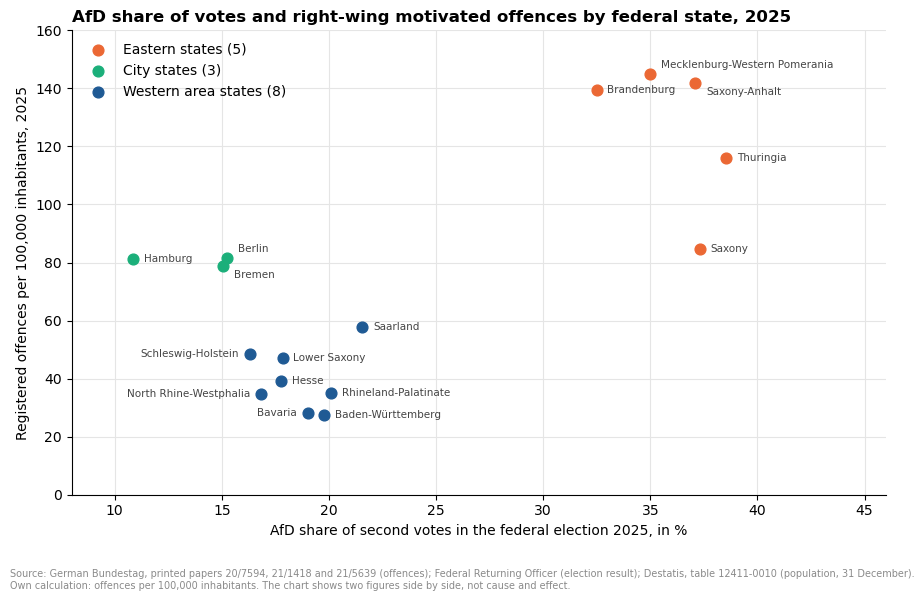

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
for group, color in GROUP_COLORS.items():
    part = data[data["group"] == group]
    ax.scatter(part["afd_share_pct"], part["total_per_100k"], color=color, s=60, zorder=3,
               label=f"{group} ({len(part)})")

# Labels stand right of the point; where points are close, the label is moved (dx, dy, alignment)
LABEL_POSITION = {
    "Schleswig-Holstein": (-0.5, 0, "right"), "North Rhine-Westphalia": (-0.5, 0, "right"),
    "Bavaria": (-0.5, 0, "right"), "Berlin": (0.5, 3, "left"), "Bremen": (0.5, -3, "left"),
    "Mecklenburg-Western Pomerania": (0.5, 3, "left"), "Saxony-Anhalt": (0.5, -3, "left"),
}
for state, row in data.iterrows():
    dx, dy, ha = LABEL_POSITION.get(state, (0.5, 0, "left"))
    ax.text(row["afd_share_pct"] + dx, row["total_per_100k"] + dy, state, fontsize=7.5, va="center", ha=ha, color="#444444")

ax.set_xlim(8, 46)
ax.set_ylim(0, 160)
ax.grid(color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("AfD share of votes and right-wing motivated offences by federal state, 2025", loc="left", fontweight="bold")
ax.set_xlabel("AfD share of second votes in the federal election 2025, in %")
ax.set_ylabel("Registered offences per 100,000 inhabitants, 2025")
ax.legend(frameon=False, loc="upper left")
fig.text(0.01, 0.01, SOURCE_STATES.replace("Destatis", "Federal Returning Officer (election result); Destatis")
         + " The chart shows two figures side by side, not cause and effect.", fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(FIGURES / "08_afd_and_offences_states.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

The chart above shows one year. The next chart shows the development in each federal state: the AfD share in all six elections from 2014 to 2025 as a line, and the offence rate as bars. The offence rate per state is available from 2022 only (Section 10), so the bars cover four years. All 16 panels use the same two scales, so the states can be compared directly.

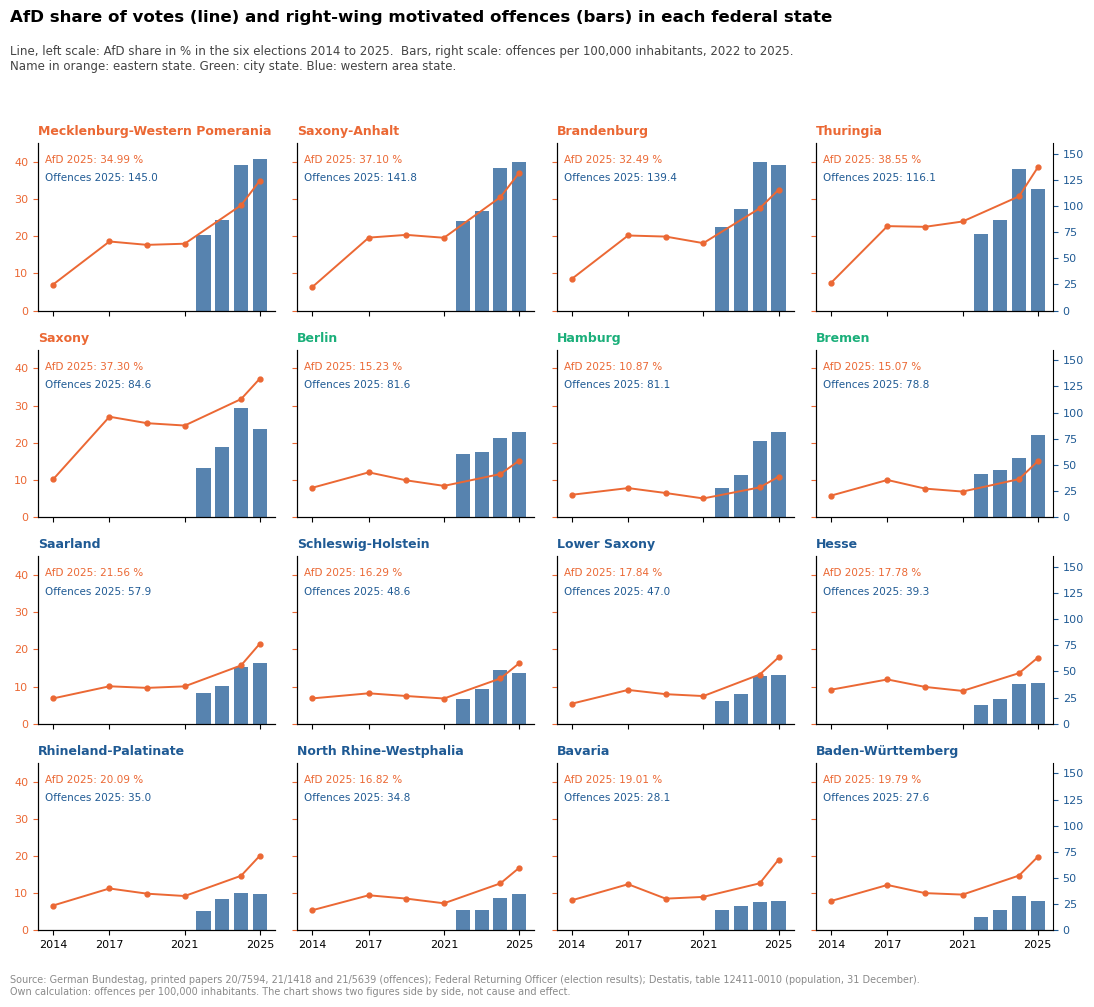

In [23]:
# One small panel per federal state, in the order of the three groups
election_years = sorted(afd["year"].unique())
share = afd[afd["state"] != "Germany"].pivot(index="year", columns="state", values="afd_share_pct")

fig, axes = plt.subplots(4, 4, figsize=(11, 10), sharex=True)
for i, (ax, state) in enumerate(zip(axes.flat, order)):
    right = ax.twinx()                              # right scale: offences per 100,000 inhabitants
    right.bar(rate.columns, rate.loc[state], color=BLUE, alpha=0.75, width=0.75, zorder=1)
    right.set_ylim(0, 160)
    right.spines["right"].set_visible(i % 4 == 3)
    right.tick_params(axis="y", labelright=i % 4 == 3, right=i % 4 == 3, labelsize=8, colors=BLUE)

    ax.set_zorder(right.get_zorder() + 1)           # left scale: AfD share, drawn in front of the bars
    ax.patch.set_visible(False)
    ax.plot(election_years, share[state], color=ORANGE, marker="o", markersize=3.5, linewidth=1.4)
    # Values of the last year in the free upper left corner of the panel
    ax.text(0.03, 0.93, f"AfD {LAST_YEAR}: {share.loc[LAST_YEAR, state]:.2f} %", transform=ax.transAxes,
            fontsize=7.5, color=ORANGE, va="top")
    ax.text(0.03, 0.82, f"Offences {LAST_YEAR}: {rate.loc[state, LAST_YEAR]:.1f}", transform=ax.transAxes,
            fontsize=7.5, color=BLUE, va="top")
    ax.set_ylim(0, 45)
    ax.set_xlim(2013.2, 2025.8)
    ax.set_xticks([2014, 2017, 2021, 2025])
    ax.tick_params(axis="y", labelleft=i % 4 == 0, labelsize=8, colors=ORANGE)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_title(state, fontsize=9, fontweight="bold", color=GROUP_COLORS[GROUP_OF_STATE[state]], loc="left")

fig.suptitle("AfD share of votes (line) and right-wing motivated offences (bars) in each federal state",
             x=0.01, y=0.995, ha="left", fontweight="bold", fontsize=12)
fig.text(0.01, 0.935, "Line, left scale: AfD share in % in the six elections 2014 to 2025.  "
         "Bars, right scale: offences per 100,000 inhabitants, 2022 to 2025.\n"
         "Name in orange: eastern state. Green: city state. Blue: western area state.", fontsize=8.5, color="#444444")
fig.text(0.01, 0.01, SOURCE_STATES.replace("Destatis", "Federal Returning Officer (election results); Destatis")
         + " The chart shows two figures side by side, not cause and effect.", fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.04, 1, 0.925))
fig.savefig(FIGURES / "09_afd_and_offences_each_state.png", dpi=150, bbox_inches="tight", pad_inches=0.2)
plt.show()

In [24]:
# Change in each state: AfD share between the federal elections 2021 and 2025, offence rate 2022 to 2025
state_change = pd.DataFrame({
    "afd_share_2021": share.loc[2021], "afd_share_2025": share.loc[2025],
    "afd_change_points": (share.loc[2025] - share.loc[2021]).round(2),
    "rate_2022": rate[FIRST_YEAR_STATES], "rate_2025": rate[LAST_YEAR],
    "rate_change": (rate[LAST_YEAR] - rate[FIRST_YEAR_STATES]).round(1),
}).loc[order]
print("States with a higher AfD share in 2025 than in 2021:", int((state_change["afd_change_points"] > 0).sum()))
print("States with a higher offence rate in 2025 than in 2022:", int((state_change["rate_change"] > 0).sum()))
print("States with a lower AfD share in 2021 than in 2017:", int((share.loc[2021] < share.loc[2017]).sum()))
state_change

States with a higher AfD share in 2025 than in 2021: 16
States with a higher offence rate in 2025 than in 2022: 16
States with a lower AfD share in 2021 than in 2017: 15


,afd_share_2021,afd_share_2025,afd_change_points,rate_2022,rate_2025,rate_change
state,,,,,,
Mecklenburg-Western Pomerania,17.99,34.99,17.00,72.5,145.0,72.5
Saxony-Anhalt,19.59,37.10,17.51,85.9,141.8,55.9
Brandenburg,18.14,32.49,14.35,80.4,139.4,59.0
Thuringia,23.97,38.55,14.58,73.4,116.1,42.7
Saxony,24.65,37.30,12.65,47.0,84.6,37.6
Berlin,8.41,15.23,6.82,60.3,81.6,21.3
Hamburg,5.03,10.87,5.84,27.9,81.1,53.2
Bremen,6.88,15.07,8.19,40.8,78.8,38.0
Saarland,10.05,21.56,11.51,29.3,57.9,28.6


**Across all 16 states the two figures move together.** The correlation is 0.72 for the federal election of 2025 and 0.85 for the European election of 2024. States with a high AfD share tend to have a high rate of right-wing motivated offences.

**This comes from the difference between the groups of states, not from a relation within them.** The chart shows three separate clusters:

- **Eastern states:** the highest AfD shares (32.5 % to 38.6 % in 2025) and the highest offence rates (84.6 to 145.0).
- **City states:** the lowest AfD shares (10.9 % to 15.2 %) and offence rates of 78.8 to 81.6, more than twice the rate of the western area states.
- **Western area states:** AfD shares of 16.3 % to 21.6 % and the lowest offence rates (27.6 to 57.9).

**Within the groups there is no such relation.** Among the eight western area states the correlation is 0.08 for 2025 and 0.23 for 2024, which is close to no relation. Among the five eastern states it is negative: −0.53 for 2025 and −0.74 for 2024. Saxony has the second-highest AfD share of all states (37.3 %) and the lowest offence rate of the five eastern states (84.6). With five and eight states these coefficients are not reliable on their own. They show that the figure for all 16 states must not be read as a general rule.

**The city states do not fit the overall pattern.** Hamburg has the lowest AfD share of all states (10.9 % in 2025) and the seventh-highest offence rate (81.1). If the offence rate simply followed the AfD share, the city states would have the lowest rates.

**In every single state both figures rose in recent years.** The AfD share in the federal election of 2025 was higher than in 2021 in all 16 states, by between 5.8 percentage points in Hamburg and 17.5 in Saxony-Anhalt. The offence rate of 2025 was higher than that of 2022 in all 16 states. Before that the AfD share had fallen: in 15 of the 16 states it was lower in 2021 than in 2017. Offence rates per state are not available for those years, so the panels cannot show whether the offences moved with it.

**What this comparison cannot show.** It compares federal states, not people. It does not say who commits offences or who votes for which party, and no conclusion about individuals follows from it. Many other things differ between the three groups, among them the recording practice of the police (Section 10). The comparison is descriptive only.

## 10. Limitations

**The statistics show registered offences, not all offences.** They count only offences that became known to the police and that the police classified as politically right-wing motivated. Offences that were not reported, or not recognised as politically motivated, are not included.

**The classification is made by the police of each state.** The police of the state responsible record and assess politically motivated offences on their own responsibility and report them to the BKA (Bundestag paper 18/5758, page 3). Differences between the states can therefore reflect differences in recording practice as well as differences in the offences committed.

**One act is counted once, with its most serious offence.** If one act fulfils several offences, the one with the highest penalty is recorded (Bundestag paper 18/5758, page 3). The types of offence therefore do not show every offence committed.

**The figures count offences, not offenders.** Nothing in these tables says who committed the offences.

**Types of offence are incomplete.** They are missing for 2015 and 2016, insult is a separate category from 2019 only, and coercion and threat is missing for 2020 and 2021. The comparison of types therefore starts in 2019 and leaves out 2020 and 2021.

**The federal states can be compared for four years only.** For 2014 to 2021 no totals per state were found in the published sources. The figures of 2022 are given by time of the offence, those of 2023 to 2025 as annual figures with the cut-off date 31 January of the following year. Whether both methods lead to the same count was not verified.

**Violent offences per state in 2025 were counted** from the list of single cases in Bundestag paper 21/5639, because the paper does not print this number per state (see `01_data_preparation.ipynb`, Section 10).

**The figures can still change.** Cases can be reported later. The figures for 2025 are the least settled.

**The comparison with election results is descriptive.** It uses 16 federal states and two points in time. It compares areas, not people, and does not control for any other difference between the states. The two types of election are not directly comparable. The grouping into eastern states, city states and western area states was made in this project; with five, three and eight states the groups are small.

**The rates use the population of 31 December.** The Bundestag papers use other reference dates, so the rates calculated here differ slightly from the printed ones.

## 11. Summary and Key Findings

- **Right-wing motivated offences rose by 150 % in eleven years.** The police registered **17,020** offences in 2014 and **42,544** in 2025. The peak is **42,788** in 2024.
- **The rise came in two steps.** The number rose by **34.9 %** in 2015, stayed between **20,431** and **23,604** until 2022, and then rose by **23.2 %** in 2023 and **47.8 %** in 2024.
- **Violent offences grew much less.** They rose from **1,029** to **1,598** (+**55.3 %**). The highest value is **1,698** in 2016. Their share in all offences fell from **6.05 %** to **3.76 %**.
- **Six in ten offences are propaganda offences.** They made up **59.0 %** of the offences in 2025, followed by incitement to hatred (**13.0 %**) and insult (**10.1 %**).
- **All types of offence rose since 2019.** Property damage (+**161.2 %**) and insult (+**142.8 %**) grew most in percent. Propaganda offences account for **53.7 %** of the additional offences.
- **The federal states differ by a factor of 5.3.** In 2025 Mecklenburg-Western Pomerania recorded **145.0** offences per 100,000 inhabitants, Baden-Württemberg **27.6**. The figure for Germany is **51.0**.
- **The rate rose in all 16 federal states from 2022 to 2025,** between **+35.3 %** in Berlin and **+190.7 %** in Hamburg.
- **The states form three groups.** In 2025 the five eastern states recorded **118.7** offences per 100,000 inhabitants, the three city states **81.2** and the eight western area states **35.1**. The eastern states have **14.8 %** of the population and **34.5 %** of the offences.
- **AfD share and offence rate move together across the 16 states** (correlation **0.72** in 2025), but not within the groups: **−0.53** among the eastern states and **0.08** among the western area states. The overall figure reflects the difference between the groups.
- **The city states do not fit the overall pattern.** They have the lowest AfD shares (**10.9 %** to **15.2 %** in 2025) and offence rates more than twice as high as the western area states.
- **The comparison with election results is descriptive.** It compares federal states, not people, and shows no cause and effect. The statistics count only offences registered and classified by the police.

## 12. Data Sources

All crime figures are published by the Federal Criminal Police Office (Bundeskriminalamt, BKA) and the Federal Ministry of the Interior (Bundesministerium des Innern, BMI), or by the German Bundestag as answers of the Federal Government to parliamentary questions. The full list of documents, with file name and page for every value, is in `01_data_preparation.ipynb` (Section 11) and in the transcribed tables `pmk_rechts_bund.csv` and `pmk_rechts_laender.csv`.

**Tables**

| Used for | Table | Built from |
|---|---|---|
| Sections 6 and 7 | `data/clean/pmk_right_federal.csv` | BKA and BMI, figures on politically motivated crime 2018 to 2025; Bundestag paper 18/5758 |
| Section 8 | `data/clean/pmk_right_states.csv` | Bundestag papers 20/7594, 21/1418 and 21/5639; Destatis, table 12411-0010 |
| Section 9 | `data/clean/afd_results.csv` | Federal Returning Officer, final results of the federal elections 2017, 2021 and 2025 and of the European elections 2014, 2019 and 2024 |

**Documents**

| Used for | Document |
|---|---|
| Recording rules of the police (Section 10) | Bundestag paper 18/5758, page 3 |
| Annual figures and cut-off date (Section 10) | Bundestag paper 21/5639, page 1 |

All rates per 100,000 inhabitants, all shares, all changes in percent, the group "other offences", the figures for Germany and for the three groups of states in Section 8, and the correlation coefficients are own calculations based on these tables.